Lejupielādēts: invoice.png


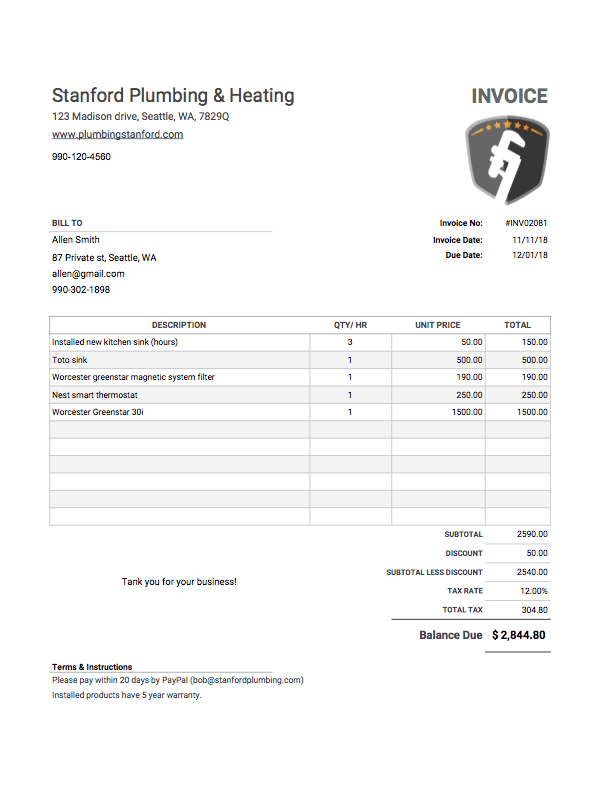

In [1]:
# 1. Rēķina parauga lejupielāde
import requests
from IPython.display import Image, display
import os

url = "https://www.invoicesimple.com/wp-content/uploads/2018/06/Sample-Invoice-printable.png"

response = requests.get(url)

if response.status_code == 200:
    with open('invoice.png', 'wb') as f:
        f.write(response.content)
    print("Lejupielādēts: invoice.png")
    display(Image('invoice.png'))
else:
    print(f"Kļūda: {response.status_code}")

In [2]:
# 2. Datu simulācija
import pandas as pd
import json

# Avots 1: E-pasts
email_data = {
    "from": "client@techcorp.com",
    "to": "accounting@devsolutions.com",
    "subject": "Invoice #INV-2024-047 — please confirm receipt",
    "date": "2024-11-15",
    "body": "Hello, please find attached the invoice for November services. Kindly verify the amounts and confirm receipt."
}

# Avots 2: CSV — piegādātāju saraksts
csv_data = """supplier_id,name,payment_days,trusted
SUP001,DevSolutions Inc,30,True
SUP002,WebAgency Ltd,14,True
SUP003,DesignStudio Co,30,False
SUP004,CloudHost Corp,7,True
"""

with open('suppliers.csv', 'w') as f:
    f.write(csv_data)

df_suppliers = pd.read_csv('suppliers.csv')
print("=== Source 2: Suppliers CSV ===")
print(df_suppliers.to_string(index=False))

# Avots 3: Webhook
webhook_data = {
    "event": "invoice.received",
    "timestamp": "2024-11-15T14:32:00Z",
    "invoice_id": "INV-2024-047",
    "sender": "DevSolutions Inc",
    "amount_expected": 4365.68,
    "currency": "USD",
    "status": "pending_review"
}

print("\n=== Source 1: Email ===")
for k, v in email_data.items():
    print(f"  {k}: {v}")

print("\n=== Source 3: Webhook ===")
print(json.dumps(webhook_data, indent=2))

=== Source 2: Suppliers CSV ===
supplier_id             name  payment_days  trusted
     SUP001 DevSolutions Inc            30     True
     SUP002    WebAgency Ltd            14     True
     SUP003  DesignStudio Co            30    False
     SUP004   CloudHost Corp             7     True

=== Source 1: Email ===
  from: client@techcorp.com
  to: accounting@devsolutions.com
  subject: Invoice #INV-2024-047 — please confirm receipt
  date: 2024-11-15
  body: Hello, please find attached the invoice for November services. Kindly verify the amounts and confirm receipt.

=== Source 3: Webhook ===
{
  "event": "invoice.received",
  "timestamp": "2024-11-15T14:32:00Z",
  "invoice_id": "INV-2024-047",
  "sender": "DevSolutions Inc",
  "amount_expected": 4365.68,
  "currency": "USD",
  "status": "pending_review"
}


In [3]:
# 3. Gemini multimodālā analīze — attēls + teksts
import requests
import base64
import json
from google.colab import userdata

# API konfigurācija
OPENROUTER_API_KEY = userdata.get('OPENROUTER_API_KEY')
MODEL = "google/gemini-2.0-flash-001"

# Attēla ielāde un base64 kodēšana
with open('invoice.png', 'rb') as f:
    image_base64 = base64.b64encode(f.read()).decode('utf-8')

# Konteksts no visiem 3 avotiem
context = f"""
EMAIL CONTEXT:
- From: {email_data['from']}
- Subject: {email_data['subject']}
- Body: {email_data['body']}

WEBHOOK DATA:
- Invoice ID: {webhook_data['invoice_id']}
- Sender: {webhook_data['sender']}
- Amount Expected: {webhook_data['amount_expected']} {webhook_data['currency']}
- Status: {webhook_data['status']}

SUPPLIER DATABASE:
{df_suppliers.to_string(index=False)}
"""

# Prompt
prompt = f"""You are an invoice processing assistant.
Analyze the attached invoice image together with the following context data:

{context}

Extract and return ONLY a JSON object with this exact structure:
{{
    "invoice_id": "extracted from image",
    "supplier_name": "extracted from image",
    "supplier_trusted": true or false (check against supplier database),
    "invoice_date": "extracted from image",
    "line_items": [
        {{"description": "...", "quantity": 0, "unit_price": 0.00, "amount": 0.00}}
    ],
    "subtotal": 0.00,
    "tax_rate": 0.00,
    "tax_amount": 0.00,
    "total": 0.00,
    "currency": "extracted from image",
    "amount_match": true or false (compare image total vs webhook amount_expected),
    "payment_days": 0 (from supplier database),
    "recommendation": "APPROVE or REVIEW or REJECT",
    "notes": "brief explanation"
}}
Return ONLY the JSON, no extra text."""

# API izsaukums
response = requests.post(
    url="https://openrouter.ai/api/v1/chat/completions",
    headers={
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json"
    },
    json={
        "model": MODEL,
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_base64}"
                        }
                    },
                    {
                        "type": "text",
                        "text": prompt
                    }
                ]
            }
        ]
    }
)

# Rezultāts
raw = response.json()
result_text = raw['choices'][0]['message']['content']
print("=== Gemini Raw Response ===")
print(result_text)

=== Gemini Raw Response ===
```json
{
    "invoice_id": "#INV02081",
    "supplier_name": "Stanford Plumbing & Heating",
    "supplier_trusted": false,
    "invoice_date": "11/11/18",
    "line_items": [
        {"description": "Installed new kitchen sink (hours)", "quantity": 3, "unit_price": 50.00, "amount": 150.00},
        {"description": "Toto sink", "quantity": 1, "unit_price": 500.00, "amount": 500.00},
        {"description": "Worcester greenstar magnetic system filter", "quantity": 1, "unit_price": 190.00, "amount": 190.00},
        {"description": "Nest smart thermostat", "quantity": 1, "unit_price": 250.00, "amount": 250.00},
        {"description": "Worcester Greenstar 301", "quantity": 1, "unit_price": 1500.00, "amount": 1500.00}
    ],
    "subtotal": 2590.00,
    "tax_rate": 12.00,
    "tax_amount": 304.80,
    "total": 2844.80,
    "currency": "$",
    "amount_match": false,
    "payment_days": 0,
    "recommendation": "REJECT",
    "notes": "The total amount does not m

In [4]:
# 4. Validācija un kļūdu apstrāde
import json

# JSON no Gemini atbildes
def parse_gemini_response(raw_text):
    try:
        clean = raw_text.strip()
        if clean.startswith("```"):
            clean = clean.split("```json")[-1].split("```")[0].strip()
        return json.loads(clean), None
    except json.JSONDecodeError as e:
        return None, f"JSON parse error: {e}"

invoice_data, error = parse_gemini_response(result_text)

if error:
    print(f"Parse failed: {error}")
else:
    print("JSON parsed successfully")

    # Validācijas pārbaudes
    validation = {
        "supplier_found":  invoice_data['supplier_trusted'],
        "amount_match":    invoice_data['amount_match'],
        "has_line_items":  len(invoice_data['line_items']) > 0,
        "total_positive":  invoice_data['total'] > 0,
        "currency_valid":  invoice_data['currency'] in ['$', 'USD', 'EUR', '€'],
    }

    print("\n=== Validation Results ===")
    for check, passed in validation.items():
      print(f"  {check}: {passed}")

    # Atbilde
    all_passed = all(validation.values())
    final_status = invoice_data['recommendation']

    print(f"\n=== Final Decision: {final_status} ===")
    print(f"  Reason: {invoice_data['notes']}")

JSON parsed successfully

=== Validation Results ===
  supplier_found: False
  amount_match: False
  has_line_items: True
  total_positive: True
  currency_valid: True

=== Final Decision: REJECT ===
  Reason: The total amount does not match the expected amount from the webhook data. I see an invoice with the ID #INV02081, issued by supplier named 'Stanford Plumbing & Heating'. This supplier is not in our trusted list. The amounts do not match DevSolutions Inc's data.


In [5]:
# 5. Rezultāta saglabāšana JSON failā
import json
from datetime import datetime

# Pilns rezultāts ar visiem avotiem
final_result = {
    "processed_at": datetime.now().isoformat(),
    "sources": {
        "email": email_data,
        "webhook": webhook_data,
        "supplier_db": df_suppliers.to_dict(orient='records')
    },
    "gemini_analysis": invoice_data,
    "validation": validation,
    "final_decision": invoice_data['recommendation']
}

with open('rezultats.json', 'w') as f:
    json.dump(final_result, f, indent=2)

print("Saved: rezultats.json")
print(json.dumps(final_result, indent=2))

Saved: rezultats.json
{
  "processed_at": "2026-05-22T11:45:02.777220",
  "sources": {
    "email": {
      "from": "client@techcorp.com",
      "to": "accounting@devsolutions.com",
      "subject": "Invoice #INV-2024-047 \u2014 please confirm receipt",
      "date": "2024-11-15",
      "body": "Hello, please find attached the invoice for November services. Kindly verify the amounts and confirm receipt."
    },
    "webhook": {
      "event": "invoice.received",
      "timestamp": "2024-11-15T14:32:00Z",
      "invoice_id": "INV-2024-047",
      "sender": "DevSolutions Inc",
      "amount_expected": 4365.68,
      "currency": "USD",
      "status": "pending_review"
    },
    "supplier_db": [
      {
        "supplier_id": "SUP001",
        "name": "DevSolutions Inc",
        "payment_days": 30,
        "trusted": true
      },
      {
        "supplier_id": "SUP002",
        "name": "WebAgency Ltd",
        "payment_days": 14,
        "trusted": true
      },
      {
        "supplier

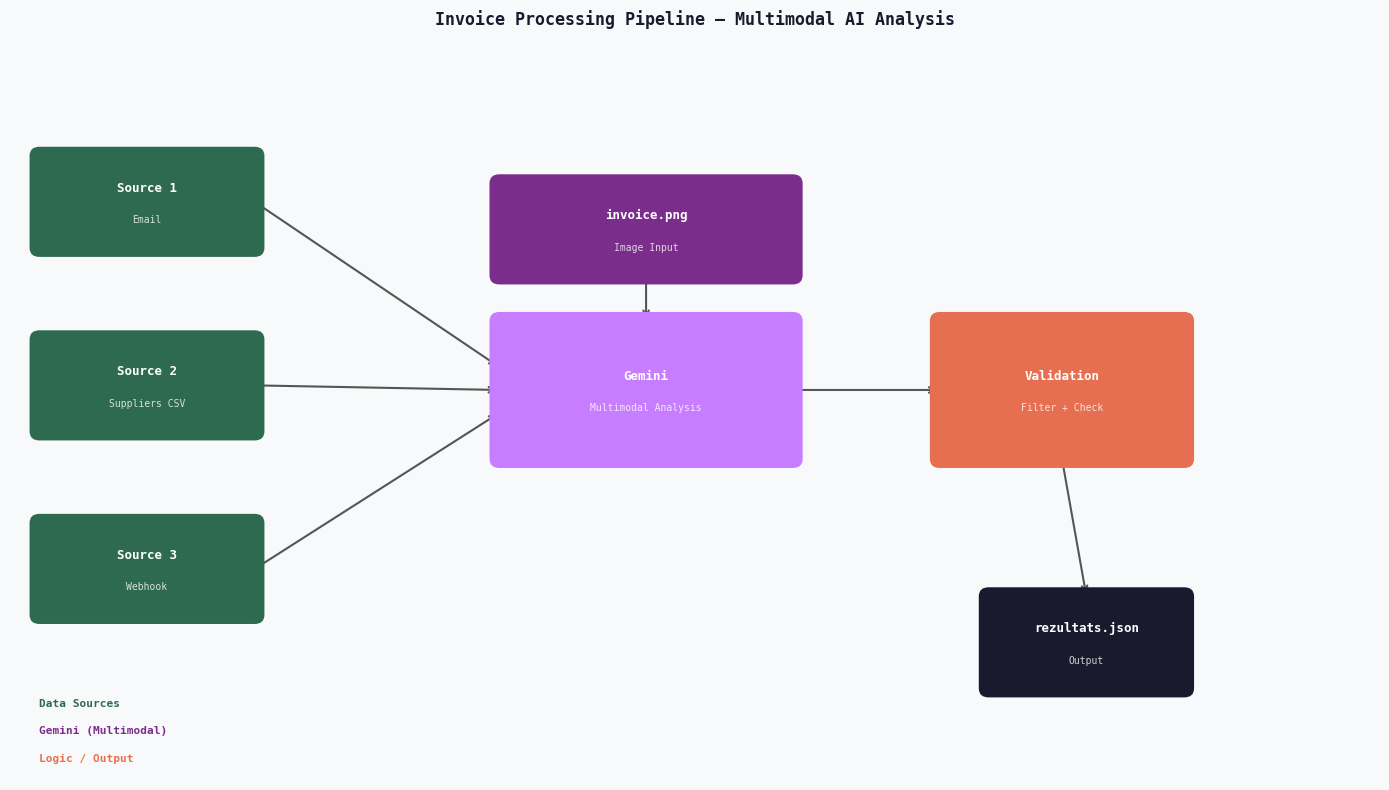

Saved: scenarijs.png


In [6]:
# 6. Scenārija ģenerēšana
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')
fig.patch.set_facecolor('#f8f9fa')

def draw_box(ax, x, y, w, h, label, sublabel='', color='#1a1a2e', textcolor='white'):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor='none', zorder=2)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2 + (0.15 if sublabel else 0), label,
            ha='center', va='center', fontsize=9, fontweight='bold',
            color=textcolor, fontfamily='monospace', zorder=3)
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.2, sublabel,
                ha='center', va='center', fontsize=7,
                color=textcolor, fontfamily='monospace', zorder=3, alpha=0.8)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5), zorder=1)

# Avoti
draw_box(ax, 0.3, 5.8, 2.2, 1.0, 'Source 1', 'Email', '#2d6a4f')
draw_box(ax, 0.3, 3.8, 2.2, 1.0, 'Source 2', 'Suppliers CSV', '#2d6a4f')
draw_box(ax, 0.3, 1.8, 2.2, 1.0, 'Source 3', 'Webhook', '#2d6a4f')

# Gemini
draw_box(ax, 5.0, 3.5, 3.0, 1.5, 'Gemini', 'Multimodal Analysis', '#c77dff')
draw_box(ax, 5.0, 5.5, 3.0, 1.0, 'invoice.png', 'Image Input', '#7b2d8b')

# Validācija
draw_box(ax, 9.5, 3.5, 2.5, 1.5, 'Validation', 'Filter + Check', '#e76f51')

# Rezultāts
draw_box(ax, 10.0, 1.0, 2.0, 1.0, 'rezultats.json', 'Output', '#1a1a2e')

# Avoti uz Gemini
draw_arrow(ax, 2.5, 6.3, 5.0, 4.5)
draw_arrow(ax, 2.5, 4.3, 5.0, 4.25)
draw_arrow(ax, 2.5, 2.3, 5.0, 4.0)

# Attēls uz Gemini
draw_arrow(ax, 6.5, 5.5, 6.5, 5.0)

# Gemini uz validāciju
draw_arrow(ax, 8.0, 4.25, 9.5, 4.25)

# Validācija uz rezultātu
draw_arrow(ax, 10.75, 3.5, 11.0, 2.0)

# Leģenda
ax.text(0.3, 0.8, 'Data Sources', fontsize=8, color='#2d6a4f',
        fontweight='bold', fontfamily='monospace')
ax.text(0.3, 0.5, 'Gemini (Multimodal)', fontsize=8, color='#7b2d8b',
        fontweight='bold', fontfamily='monospace')
ax.text(0.3, 0.2, 'Logic / Output', fontsize=8, color='#e76f51',
        fontweight='bold', fontfamily='monospace')

ax.set_title('Invoice Processing Pipeline — Multimodal AI Analysis',
             fontsize=12, fontweight='bold', fontfamily='monospace',
             color='#1a1a2e', pad=15)

plt.tight_layout()
plt.savefig('scenarijs.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("Saved: scenarijs.png")

In [7]:
# 7. Promptu saglabāšana
prompt_content = """=== INVOICE PROCESSING PIPELINE — PROMPTS ===

--- GEMINI MULTIMODAL PROMPT ---

You are an invoice processing assistant.
Analyze the attached invoice image together with the following context data:

EMAIL CONTEXT:
- From: {email_from}
- Subject: {email_subject}
- Body: {email_body}

WEBHOOK DATA:
- Invoice ID: {invoice_id}
- Sender: {sender}
- Amount Expected: {amount_expected} {currency}
- Status: {status}

SUPPLIER DATABASE:
{supplier_table}

Extract and return ONLY a JSON object with this exact structure:
{
    "invoice_id": "extracted from image",
    "supplier_name": "extracted from image",
    "supplier_trusted": true or false (check against supplier database),
    "invoice_date": "extracted from image",
    "line_items": [
        {"description": "...", "quantity": 0, "unit_price": 0.00, "amount": 0.00}
    ],
    "subtotal": 0.00,
    "tax_rate": 0.00,
    "tax_amount": 0.00,
    "total": 0.00,
    "currency": "extracted from image",
    "amount_match": true or false (compare image total vs webhook amount_expected),
    "payment_days": 0 (from supplier database),
    "recommendation": "APPROVE or REVIEW or REJECT",
    "notes": "brief explanation"
}
Return ONLY the JSON, no extra text.
"""

with open('prompti.txt', 'w') as f:
    f.write(prompt_content)

print("Saved: prompti.txt")

Saved: prompti.txt


# Rēķina datu analīze ar Gemini Make.

## 1. Izmantotie datu avoti

Scenārijā tiek izmantoti trīs datu avoti:

**Source 1 — Email**
Simulē ienākošu e-pastu no klienta ar pieprasījumu apstiprināt rēķinu. Satur metadatus: sūtītājs, saņēmējs, temats, datums un ziņojuma teksts.

**Source 2 — Suppliers CSV**
CSV fails ar piegādātāju references datiem — nosaukums, maksājuma termiņš, uzticamības statuss. Nolasīts ar `pandas`. Izmantots kā references datu bāze Gemini kontekstam.

**Source 3 — Webhook**
JSON struktūra simulē reāllaika API paziņojumu par saņemtu rēķinu. Satur rēķina ID, gaidāmo summu un statusu.

## 2. Gemini izmantošanas veids

Gemini modelis (`google/gemini-2.0-flash-001`) tiek izsaukts caur OpenRouter API ar multimodālu pieprasījumu — vienā API izsaukumā tiek nosūtīti:

- **Attēls** — rēķina PNG fails, kodēts base64 formātā
- **Teksts** — apvienots konteksts no visiem trim avotiem

Gemini uzdevums ir izvilkt strukturētu informāciju no attēla un salīdzināt to ar teksta kontekstu — pārbaudīt piegādātāju, salīdzināt summas un pieņemt lēmumu.

## 3. Kāpēc risinājums ir multimodāls

Risinājums ir multimodāls, jo Gemini vienlaikus apstrādā divus dažādus datu veidus:

- **Attēls** — rēķina vizuālais saturs (pakalpjums, summas, datums, piegādātāja nosaukums)
- **Teksts** — strukturēti dati no e-pasta, webhook un CSV

Neviens no šiem avotiem viens pats nav pietiekams. Tikai apvienojot attēlu ar teksta kontekstu ir iespējams veikt pilnvērtīgu validāciju — pārbaudīt vai rēķina summa atbilst gaidītajai, vai piegādātājs ir reģistrēts un uzticams.

## 4. Automatizācijas loģika

Scenārijā ir ieviesta validācija ar piecām pārbaudēm:

- `supplier_found` — vai piegādātājs ir suppliers sarakstā
- `amount_match` — vai rēķina summa atbilst webhook datiem
- `has_line_items` — vai rēķinā ir vismaz viena pozīcija
- `total_positive` — vai kopējā summa ir pozitīva
- `currency_valid` — vai valūta ir atpazīta

Pamatojoties uz šīm pārbaudēm Gemini atgriež rekomendāciju: `APPROVE`, `REVIEW` vai `REJECT`.

## 5. Tehnoloģijas

| Komponente | Tehnoloģija |
|---|---|
| Vide | Google Colab |
| Multimodālais modelis | Gemini 2.0 Flash |
| API piekļuve | OpenRouter API |
| Datu apstrāde | Python, pandas |
| Attēlu kodēšana | base64 |
| Rezultāts | JSON |

## 6. GDPR apsvērumi

Šajā projektā visi dati ir fiktīvi — nav izmantoti reāli personas dati, tāpēc GDPR prasības netiek pārkāptas.

Tomēr praksē būtu jāņem vērā:

- Rēķinos bieži ir personas dati (vārds, uzvārds, adrese) — tie ir aizsargājami pēc GDPR
- Sūtot attēlus uz OpenRouter API, dati nonāk trešo pušu serveros — tas bez DPA (Data Processing Agreement) var pārkāpt GDPR
- **Risinājumi reālā projektā:**
  - Izmantot Gemini API caur Google Cloud ES reģionu
  - Anonimizēt sensitīvus datus pirms sūtīšanas uz API
  - Vai izmantot lokālu multimodālu modeli (piemēram, Ollama + LLaVA)